In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("/Users/ostappolukainen/Desktop/ProjRED")
ACCEPTED = DATA_DIR / "accepted_slim.csv"

In [2]:
df = pd.read_csv(
    ACCEPTED,
    parse_dates=["issue_d", "last_pymnt_d", "earliest_cr_line"],
    date_format="%b-%Y",
    dtype={
        "id": "string",
        "term": "string",          # " 36 months" / " 60 months" — strip whitespace later
        "int_rate": "string",      # already numeric in this file (e.g. "13.99") — cast with .astype(float)
        "revol_util": "string",    # same — already numeric here
        "emp_length": "string",    # "10+ years" / "< 1 year" — needs mapping
        "grade": "category",
        "sub_grade": "category",
        "purpose": "category",
        "home_ownership": "category",
        "verification_status": "category",
        "addr_state": "category",
        "loan_status": "category",
        "application_type": "category",
        "hardship_flag": "category",
        "debt_settlement_flag": "category",
    },
    low_memory=False,
)
df.shape

(2260701, 44)

In [3]:
df.dtypes

id                                    string
issue_d                       datetime64[us]
loan_amnt                            float64
funded_amnt                          float64
term                                  string
int_rate                              string
installment                          float64
grade                               category
sub_grade                           category
purpose                             category
loan_status                         category
application_type                    category
emp_length                            string
home_ownership                      category
annual_inc                           float64
verification_status                 category
dti                                  float64
addr_state                          category
fico_range_low                       float64
fico_range_high                      float64
last_fico_range_low                  float64
last_fico_range_high                 float64
earliest_c

In [4]:
df["loan_status"].value_counts(dropna=False)

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
NaN                                                         33
Name: count, dtype: int64

In [5]:
# 1. term: strip leading space, then extract the number
df["term"] = df["term"].str.strip()
df["term_months"] = df["term"].str.extract(r"(\d+)")[0].astype("Int64")  # Int64 = nullable int (33 rows have NaN term)

# 2. int_rate and revol_util: already numeric strings, just cast
df["int_rate"] = df["int_rate"].astype(float)
df["revol_util"] = df["revol_util"].astype(float)   # has NaN — astype handles them

# 3. emp_length: text → numeric years
emp_length_map = {
    "< 1 year": 0,
    "1 year":   1,
    "2 years":  2,
    "3 years":  3,
    "4 years":  4,
    "5 years":  5,
    "6 years":  6,
    "7 years":  7,
    "8 years":  8,
    "9 years":  9,
    "10+ years": 10,
}
df["emp_length_years"] = df["emp_length"].map(emp_length_map)
# unmatched values (incl. "n/a" or NaN) become NaN — OK, treat as missing

In [6]:
print(df["term_months"].value_counts())             # should show 36 and 60
print(df["int_rate"].describe())                    # min ~5, max ~31
print(df["emp_length_years"].value_counts(dropna=False))  # 0..10 plus NaN

term_months
36    1609754
60     650914
Name: count, dtype: Int64
count    2.260668e+06
mean     1.309283e+01
std      4.832138e+00
min      5.310000e+00
25%      9.490000e+00
50%      1.262000e+01
75%      1.599000e+01
max      3.099000e+01
Name: int_rate, dtype: float64
emp_length_years
10.0    748005
2.0     203677
0.0     189988
3.0     180753
1.0     148403
NaN     146940
5.0     139698
4.0     136605
6.0     102628
7.0      92695
8.0      91914
9.0      79395
Name: count, dtype: int64


In [7]:
# --- Label mapping: loan_status -> default_flag (None = drop the row) ---
LOAN_STATUS_MAP = {
    "Fully Paid":                                          0,
    "Charged Off":                                         1,
    "Default":                                             1,
    "Does not meet the credit policy. Status:Fully Paid":  1,
    "Current":                                             None,
    "Late (16-30 days)":                                   None,
    "Late (31-120 days)":                                  None,
    "In Grace Period":                                     None,
    "Does not meet the credit policy. Status:Charged Off": None,
}

rows_in = len(df)

# Tally drop reasons (everything not mapped to 0/1, plus null)
keep_statuses = {k for k, v in LOAN_STATUS_MAP.items() if v is not None}
status_counts = df["loan_status"].value_counts(dropna=False)
dropped_by_reason = {}
for status, count in status_counts.items():
    if pd.isna(status):
        dropped_by_reason["<null>"] = int(count)
    elif status not in keep_statuses:
        dropped_by_reason[str(status)] = int(count)

# Apply mapping; drop rows that don't have a 0/1 label
labels = df["loan_status"].map(LOAN_STATUS_MAP)
labeled = df.assign(default_flag=labels).dropna(subset=["default_flag"]).copy()
labeled["default_flag"] = labeled["default_flag"].astype("int8")

# --- Validation: fail loudly ---
assert labeled["default_flag"].isna().sum() == 0, "default_flag has nulls"
assert set(labeled["default_flag"].unique()) <= {0, 1}, "default_flag is not binary"
expected_kept = sum(int((df["loan_status"] == s).sum()) for s in keep_statuses)
assert len(labeled) == expected_kept, f"row count mismatch: kept={len(labeled)} expected={expected_kept}"

# --- Write parquet ---
# Convert pandas "string" extension dtype to plain object — works around a
# pyarrow/Jupyter-kernel issue ("arrow.py_extension_type not found").
out_df = labeled.copy()
for col in out_df.select_dtypes(include=["string"]).columns:
    out_df[col] = out_df[col].astype(object)

OUT_DIR = DATA_DIR / "data"
OUT_DIR.mkdir(exist_ok=True)
OUT_PATH = OUT_DIR / "accepted_labeled.parquet"
out_df.to_parquet(OUT_PATH, index=False)

# --- Diagnostics ---
counts = labeled["default_flag"].value_counts().sort_index()
n_zero = int(counts.get(0, 0))
n_one = int(counts.get(1, 0))
default_rate = n_one / len(labeled) * 100

print(f"rows in:      {rows_in:>10,}")
print(f"rows kept:    {len(labeled):>10,}")
print(f"rows dropped: {rows_in - len(labeled):>10,}")
print()
print("dropped by reason:")
for status, count in sorted(dropped_by_reason.items(), key=lambda x: -x[1]):
    print(f"  {status:<55} {count:>10,}")
print()
print(f"default_flag = 0 (Fully Paid):           {n_zero:>10,}")
print(f"default_flag = 1 (Charged Off + Default + DNMCP:FP): {n_one:>10,}")
print(f"default rate:                              {default_rate:>5.2f}%")
print()
print(f"wrote: {OUT_PATH}")

rows in:       2,260,701
rows kept:     1,347,338
rows dropped:    913,363

dropped by reason:
  Current                                                    878,317
  Late (31-120 days)                                          21,467
  In Grace Period                                              8,436
  Late (16-30 days)                                            4,349
  Does not meet the credit policy. Status:Charged Off            761
  <null>                                                          33

default_flag = 0 (Fully Paid):            1,076,751
default_flag = 1 (Charged Off + Default + DNMCP:FP):    270,587
default rate:                              20.08%

wrote: /Users/ostappolukainen/Desktop/ProjRED/data/accepted_labeled.parquet


## Thing 1 — Loan volume over time
Counts of originated loans per year. Most training data is concentrated in 2014–2017.

issue_d
2007.0       603
2008.0      2393
2009.0      5281
2010.0     12537
2011.0     21721
2012.0     53367
2013.0    134814
2014.0    235629
2015.0    421095
2016.0    434407
2017.0    443579
2018.0    495242
dtype: int64


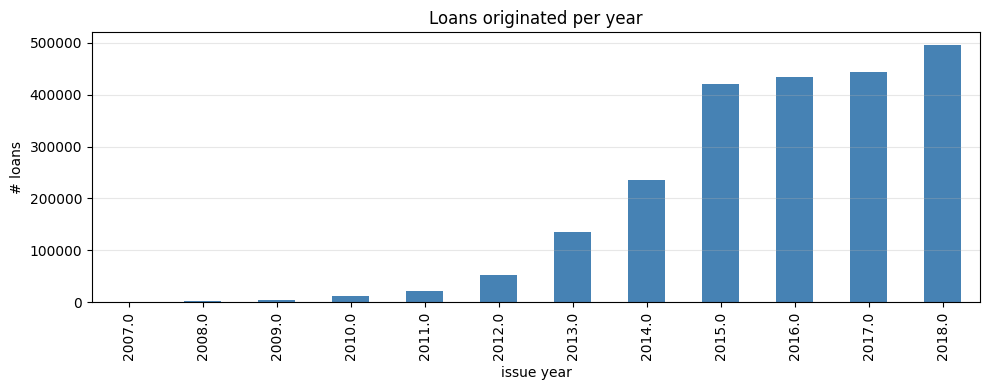

In [8]:
vol_per_year = df.groupby(df["issue_d"].dt.year).size()
print(vol_per_year)

ax = vol_per_year.plot(kind="bar", figsize=(10, 4), color="steelblue")
ax.set_title("Loans originated per year")
ax.set_xlabel("issue year")
ax.set_ylabel("# loans")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Thing 2 — Default rate by grade
Primary sanity check: rates should rise monotonically A → G.

         size  rate_pct
grade                  
A      235185      6.08
B      393017     13.45
C      382175     22.54
D      201460     30.56
E       94034     38.73
F       32213     45.47
G        9254     50.59

monotonic A→G: True


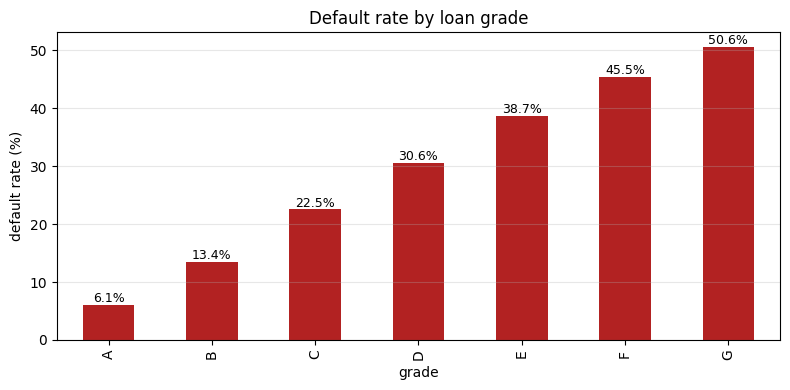

In [9]:
by_grade = labeled.groupby("grade", observed=True)["default_flag"].agg(["mean", "size"])
by_grade["rate_pct"] = by_grade["mean"] * 100
by_grade = by_grade[["size", "rate_pct"]].sort_index()
print(by_grade.round(2))

monotonic = (by_grade["rate_pct"].diff().dropna() >= 0).all()
print(f"\nmonotonic A→G: {monotonic}")

ax = by_grade["rate_pct"].plot(kind="bar", figsize=(8, 4), color="firebrick")
ax.set_title("Default rate by loan grade")
ax.set_xlabel("grade")
ax.set_ylabel("default rate (%)")
ax.grid(axis="y", alpha=0.3)
for i, v in enumerate(by_grade["rate_pct"]):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## Thing 3 — Default rate by FICO band, purpose, term, home_ownership
Where the risk is concentrated in the portfolio.

=== FICO band ===
             size  rate_pct
fico_band                  
<660          338     99.41
660-700    821809     23.68
700-740    379826     16.20
740-780    107028     10.61
>=780       38337      7.14

=== purpose ===
                      size  rate_pct
purpose                             
educational            391     30.95
small_business       15505     30.11
renewable_energy       935     23.85
moving                9511     23.60
house                 7287     22.25
medical              15592     21.97
other                78180     21.35
debt_consolidation  781150     21.23
vacation              9078     19.29
major_purchase       29527     18.88
home_improvement     87650     17.85
credit_card         295556     17.00
car                  14639     14.99
wedding               2337     13.78

=== term_months ===
                size  rate_pct
term_months                   
60            324781     32.49
36           1022557     16.14

=== home_ownership ===
        

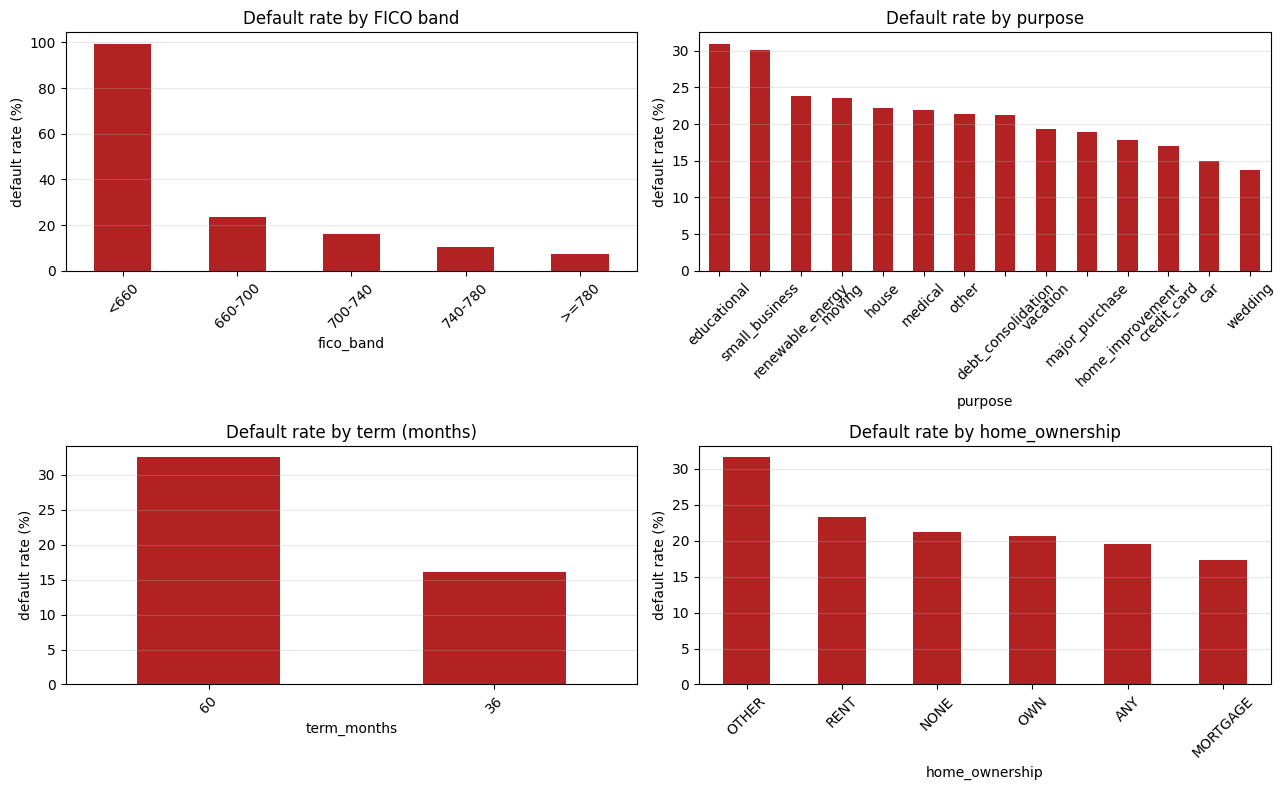

In [10]:
# FICO bands
FICO_BINS = [0, 660, 700, 740, 780, 1000]
FICO_LABELS = ["<660", "660-700", "700-740", "740-780", ">=780"]
labeled["fico_band"] = pd.cut(labeled["fico_range_low"], bins=FICO_BINS, labels=FICO_LABELS, right=False)

def rate_table(col):
    g = labeled.groupby(col, observed=True)["default_flag"].agg(["mean", "size"])
    g["rate_pct"] = g["mean"] * 100
    return g[["size", "rate_pct"]].sort_values("rate_pct", ascending=False)

fico_tbl = labeled.groupby("fico_band", observed=True)["default_flag"].agg(["mean", "size"])
fico_tbl["rate_pct"] = fico_tbl["mean"] * 100
fico_tbl = fico_tbl[["size", "rate_pct"]]

print("=== FICO band ===")
print(fico_tbl.round(2))
print("\n=== purpose ===")
print(rate_table("purpose").round(2))
print("\n=== term_months ===")
print(rate_table("term_months").round(2))
print("\n=== home_ownership ===")
print(rate_table("home_ownership").round(2))

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (title, tbl) in zip(
    axes.flat,
    [("FICO band", fico_tbl),
     ("purpose", rate_table("purpose")),
     ("term (months)", rate_table("term_months")),
     ("home_ownership", rate_table("home_ownership"))],
):
    tbl["rate_pct"].plot(kind="bar", ax=ax, color="firebrick")
    ax.set_title(f"Default rate by {title}")
    ax.set_ylabel("default rate (%)")
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## Thing 4 — Distributions and missing rates
Numeric: min, max, mean, median, p1, p99 + histogram. Categorical: value counts. Missing %: candidates for imputation/dropping.

In [11]:
numeric_cols = labeled.select_dtypes(include=np.number).columns.tolist()
stats = labeled[numeric_cols].agg([
    "min", "max", "mean", "median",
    lambda s: s.quantile(0.01),
    lambda s: s.quantile(0.99),
]).T
stats.columns = ["min", "max", "mean", "median", "p1", "p99"]
print(stats.round(2).to_string())

                               min          max      mean    median        p1        p99
loan_amnt                   500.00     40000.00  14411.76  12000.00   1500.00   35000.00
funded_amnt                 500.00     40000.00  14403.10  12000.00   1500.00   35000.00
int_rate                      5.31        30.99     13.24     12.74      5.32      26.30
installment                   4.93      1719.83    437.85    375.06     52.76    1220.57
annual_inc                    0.00  10999200.00  76241.53  65000.00  18000.00  251000.00
dti                          -1.00       999.00     18.28     17.61      1.77      38.47
fico_range_low              610.00       845.00    696.17    690.00    660.00     800.00
fico_range_high             614.00       850.00    700.17    694.00    664.00     804.00
last_fico_range_low           0.00       845.00    660.17    690.00      0.00     815.00
last_fico_range_high          0.00       850.00    677.28    694.00    499.00     819.00
delinq_2yrs          

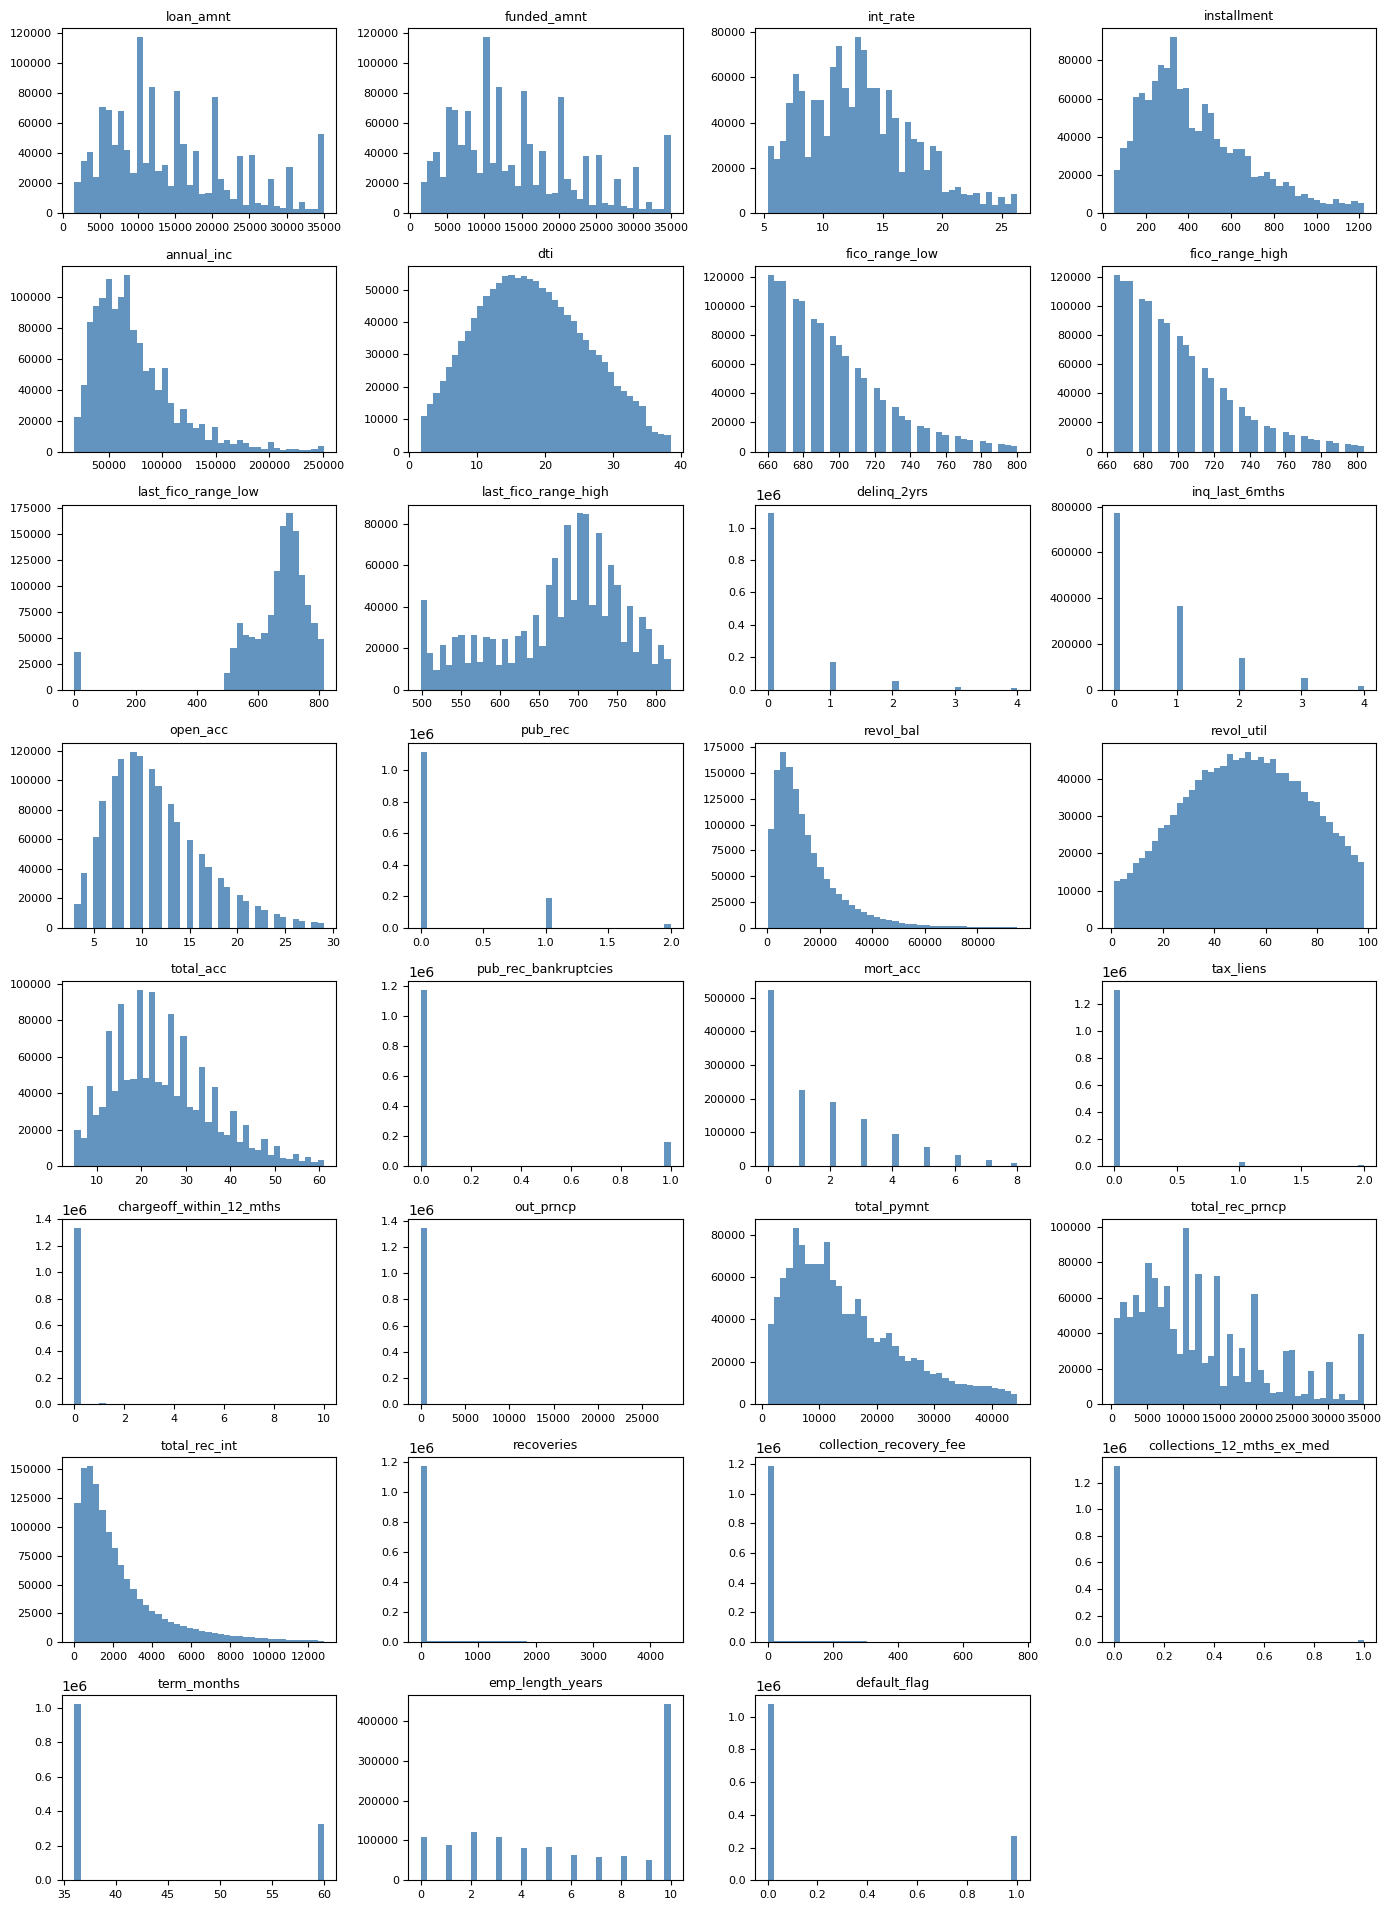

In [12]:
# Histograms (clipped to [p1, p99] for readability — raw range shown in the stats table above)
n = len(numeric_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 2.4 * nrows))
for ax, col in zip(axes.flat, numeric_cols):
    s = labeled[col].dropna()
    if len(s) == 0:
        ax.set_visible(False)
        continue
    lo, hi = s.quantile(0.01), s.quantile(0.99)
    if lo == hi:
        lo, hi = s.min(), s.max()
    s_clip = s[(s >= lo) & (s <= hi)]
    ax.hist(s_clip, bins=40, color="steelblue", alpha=0.85)
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=8)
for ax in axes.flat[n:]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

In [13]:
# Categorical value counts
cat_cols = labeled.select_dtypes(include=["category", "object", "string"]).columns.tolist()
for col in cat_cols:
    vc = labeled[col].value_counts(dropna=False)
    print(f"=== {col} ({labeled[col].nunique(dropna=True)} unique) ===")
    print(vc.head(15))
    if len(vc) > 15:
        print(f"... +{len(vc) - 15} more")
    print()

=== id (1347338 unique) ===
id
68407277    1
68355089    1
68341763    1
68476807    1
68426831    1
68476668    1
67275481    1
68466926    1
68616873    1
68338832    1
66624733    1
68466961    1
68354783    1
68466916    1
68577849    1
Name: count, dtype: int64[pyarrow]
... +1347323 more

=== term (2 unique) ===
term
36 months    1022557
60 months     324781
Name: count, dtype: int64[pyarrow]

=== grade (7 unique) ===
grade
B    393017
C    382175
A    235185
D    201460
E     94034
F     32213
G      9254
Name: count, dtype: int64

=== sub_grade (35 unique) ===
sub_grade
C1    85596
B4    83253
B5    82615
B3    81889
C2    79320
C3    75095
C4    74526
B2    74069
B1    71191
C5    67638
A5    64051
A4    52255
D1    51410
D2    44941
A1    43682
Name: count, dtype: int64
... +20 more

=== purpose (14 unique) ===
purpose
debt_consolidation    781150
credit_card           295556
home_improvement       87650
other                  78180
major_purchase         29527
medical        

In [14]:
# Missing rates
missing_pct = (labeled.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
print("missing rate (%):")
print(missing_pct.round(2))

# Highlight thresholds
drop_candidates = missing_pct[missing_pct > 30].index.tolist()
impute_candidates = missing_pct[(missing_pct >= 1) & (missing_pct <= 30)].index.tolist()
print(f"\n>30% missing (drop candidates): {drop_candidates}")
print(f"1–30% missing (impute candidates): {impute_candidates}")

# Specific outlier checks
print(f"\nannual_inc max: {labeled['annual_inc'].max():,.0f} (p99: {labeled['annual_inc'].quantile(0.99):,.0f})")
print(f"dti max: {labeled['dti'].max()} | rows with dti==999: {(labeled['dti'] == 999).sum():,}")
print(f"revol_util max: {labeled['revol_util'].max():.1f} | rows with revol_util>100: {(labeled['revol_util'] > 100).sum():,}")

missing rate (%):
emp_length_years              5.83
emp_length                    5.83
mort_acc                      3.66
last_pymnt_d                  0.17
pub_rec_bankruptcies          0.09
revol_util                    0.07
dti                           0.03
collections_12_mths_ex_med    0.01
chargeoff_within_12_mths      0.01
tax_liens                     0.01
inq_last_6mths                0.00
open_acc                      0.00
total_acc                     0.00
delinq_2yrs                   0.00
earliest_cr_line              0.00
pub_rec                       0.00
annual_inc                    0.00
dtype: float64

>30% missing (drop candidates): []
1–30% missing (impute candidates): ['emp_length_years', 'emp_length', 'mort_acc']



annual_inc max: 10,999,200 (p99: 251,000)
dti max: 999.0 | rows with dti==999: 38
revol_util max: 892.3 | rows with revol_util>100: 4,704


### Findings (data dictionary)
- **annual_inc** has values up to ~$11M — clearly data-entry errors. Plan: cap at 99th percentile (~$251K) before modeling.
- **dti** has a max of 999.0 (38 rows) — placeholder for "unknown". Treat as missing (`df.loc[df.dti == 999, "dti"] = pd.NA`).
- **revol_util** has values above 100% (~4,700 rows, max ~892%) — outliers. Consider clipping at 150% or treating extremes as missing.
- **emp_length** is null in ~5.8% of rows (treated as `emp_length_years = NaN`). Imputation candidate (median or "unknown" bucket).
- **mort_acc** missing in ~3.7% of rows — impute.
- No columns with >30% missing → no immediate drop candidates.
- **fico_range_low / fico_range_high** are at-origination scores; **last_fico_range_*** are observed at last credit pull and have a huge zero-mass for charged-off loans (FICO=0 placeholder). For modeling at origination, use fico_range_low only.
- **out_prncp / total_pymnt / recoveries** are post-origination outcome variables — leak the label. Exclude from features.

## Thing 5 — Vintage curves
Cumulative default rate at months 1, 6, 12, 24, 36 since origination, one line per origination year.
Charge-off date is approximated by `last_pymnt_d` (the standard proxy when actual charge-off date isn't available).
Late vintages (2017–2018) are truncated because loans haven't had time to mature.

as_of: 2019-04-01


month    1      6      12     24     36
year                                   
2007   0.20   1.43   7.35  16.12  47.55
2008   0.42   2.99   6.62  16.37  33.02
2009   0.27   2.81   6.27  12.17  18.13
2010   0.09   1.82   4.85   9.82  14.49
2011   0.11   2.01   4.89  10.03  13.27
2012   0.14   2.03   5.45  11.44  15.08
2013   0.13   1.65   4.72  10.59  14.15
2014   0.12   1.90   5.50  12.56  16.98
2015   0.14   2.32   6.78  14.92  19.46
2016   0.22   3.69  10.04  20.05  21.11
2017   0.46   6.39  16.10  22.76    NaN
2018   1.11  11.95  18.71    NaN    NaN


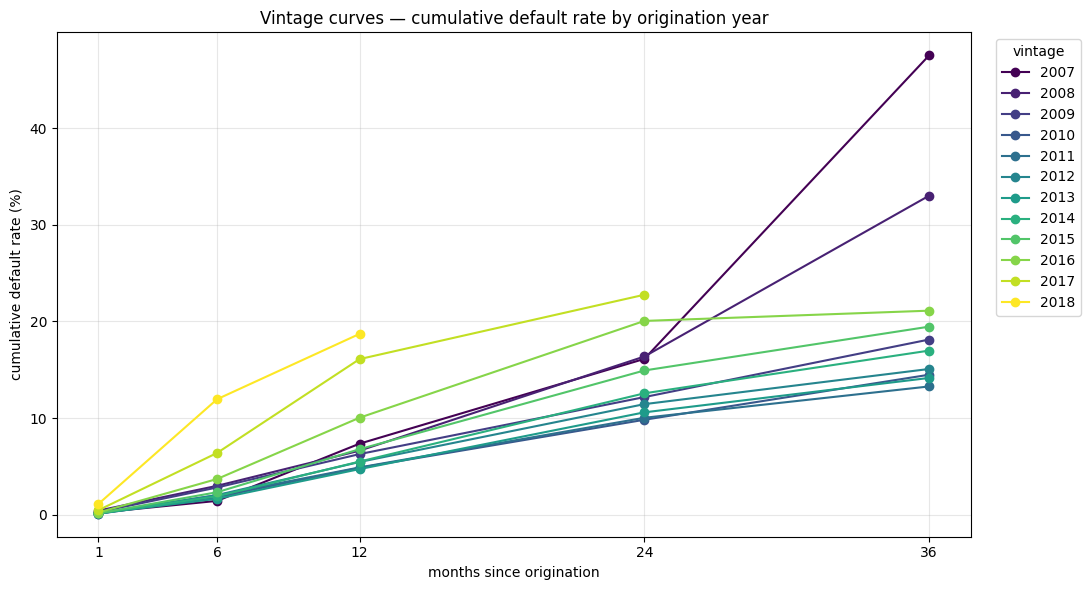

In [15]:
vc = labeled.copy()
vc["origin_year"] = vc["issue_d"].dt.year

# Approximate dataset cutoff ("as of") from latest payment date
as_of = vc["last_pymnt_d"].max() + pd.DateOffset(months=1)
print(f"as_of: {as_of.date()}")

vc["maturity_months"] = (
    (as_of.year - vc["issue_d"].dt.year) * 12
    + (as_of.month - vc["issue_d"].dt.month)
)
vc["months_to_default"] = (
    (vc["last_pymnt_d"].dt.year - vc["issue_d"].dt.year) * 12
    + (vc["last_pymnt_d"].dt.month - vc["issue_d"].dt.month)
)

MILESTONES = [1, 6, 12, 24, 36]
years = sorted(int(y) for y in vc["origin_year"].dropna().unique())

rows = []
for year in years:
    v = vc[vc["origin_year"] == year]
    for m in MILESTONES:
        obs = v[v["maturity_months"] >= m]
        if len(obs) < 100:  # skip vintages with too few observable loans at this milestone
            continue
        defaulted = obs[(obs["default_flag"] == 1) & (obs["months_to_default"] <= m)]
        rows.append({
            "year": year,
            "month": m,
            "cum_default_rate": len(defaulted) / len(obs) * 100,
            "n_obs": len(obs),
        })
vintage = pd.DataFrame(rows)
pivot = vintage.pivot(index="year", columns="month", values="cum_default_rate")
print(pivot.round(2))

fig, ax = plt.subplots(figsize=(11, 6))
cmap = plt.cm.viridis
for i, year in enumerate(pivot.index):
    series = pivot.loc[year].dropna()
    ax.plot(series.index, series.values, marker="o",
            color=cmap(i / max(1, len(pivot.index) - 1)),
            label=str(year))
ax.set_xlabel("months since origination")
ax.set_ylabel("cumulative default rate (%)")
ax.set_title("Vintage curves — cumulative default rate by origination year")
ax.set_xticks(MILESTONES)
ax.grid(alpha=0.3)
ax.legend(title="vintage", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()